# Credit Card Fraud Detection

## Objective
The objective of this project is to build a machine learning model that can accurately detect fraudulent credit card transactions. The dataset is highly imbalanced, with a small proportion of transactions being fraudulent. The project involves handling this class imbalance and evaluating the model's effectiveness in detecting fraud.

## Tools and Techniques

### Tools:
- **Pandas:** For data manipulation and analysis.
- **Matplotlib:** For data visualization (e.g., creating pie charts).
- **Scikit-learn:** For machine learning models and evaluation metrics.
- **Imbalanced-learn (SMOTE):** For handling class imbalance by oversampling the minority class.

### Techniques:
- **Data Preprocessing:** Clean the dataset, handle missing values, and scale features.
- **Class Imbalance Handling:** Use SMOTE to oversample fraudulent transactions and balance the dataset.
- **Model Building:** Train a Random Forest Classifier to classify transactions as fraudulent or non-fraudulent.
- **Model Evaluation:** Evaluate model performance using metrics like confusion matrix, classification report, and ROC-AUC score.
- **Visualization:** Create visualizations, such as pie charts, to understand class distribution in the dataset.



# Importing Rquired Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

## Data loading and exploration

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Checking Missing Values and Duplicates

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

# Check the Class Distribution

In [10]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## Pie plot 

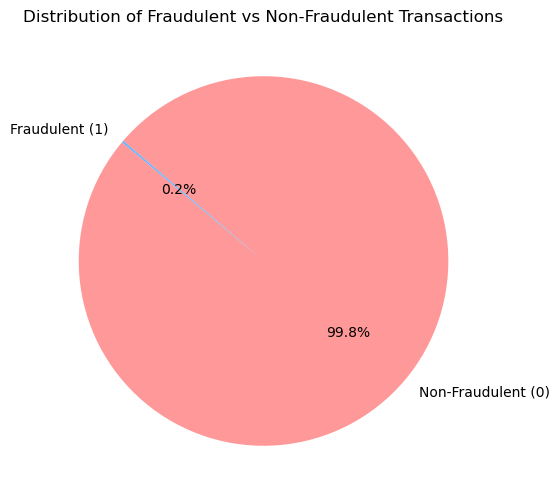

In [11]:
class_counts = df['Class'].value_counts()
labels = ['Non-Fraudulent (0)', 'Fraudulent (1)']
sizes = class_counts.values
colors = ['#ff9999','#66b3ff']  # Colors for the pie slices

# Create the pie chart
plt.figure(figsize=(8,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.show()

# Data Preprocessing

In [12]:
X = df.drop('Class',axis=1)
y = df['Class']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Scale the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handling Imbalanced Data

In [14]:
# Handle Class Imbalance Using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

C:\Users\PMLS\anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


### Check the new Class Distribution after SMOTE

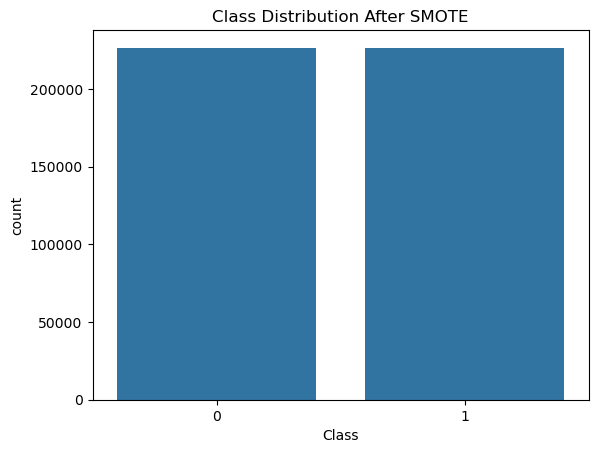

In [15]:
sns.countplot(x=y_train_smote)
plt.title('Class Distribution After SMOTE')
plt.show()

In [16]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({0: 226597, 1: 383})
After SMOTE: Counter({0: 226597, 1: 226597})


# Model Building and Trainning

In [17]:
# Build Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=50,     # default is 100 — reduce for speed
    max_depth=10,        # limit tree depth
    random_state=42,
    n_jobs=-1            # use all CPU cores (speeds up training)
)

In [18]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=10, random_state=42)

## Model Evaluation

In [19]:
# Predict on Test Data
y_pred = rf.predict(X_test_scaled)

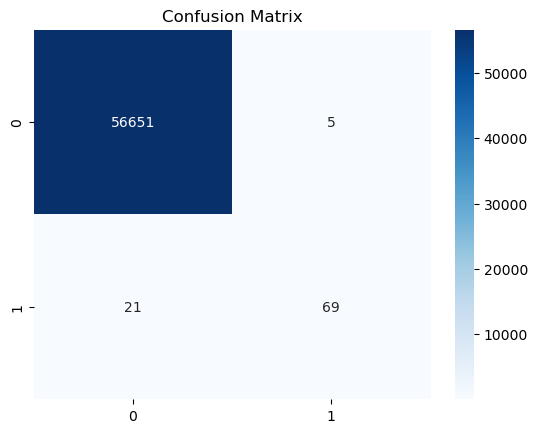

In [20]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.93      0.77      0.84        90

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [22]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred)
print(f'ROC-AUC Score: {roc_auc}')

ROC-AUC Score: 0.8832892073802127


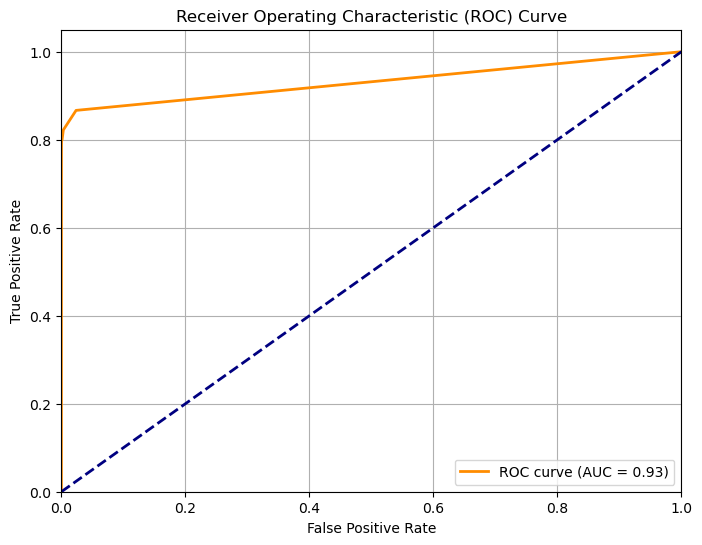

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities from the random forest classifier
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Feature Importance

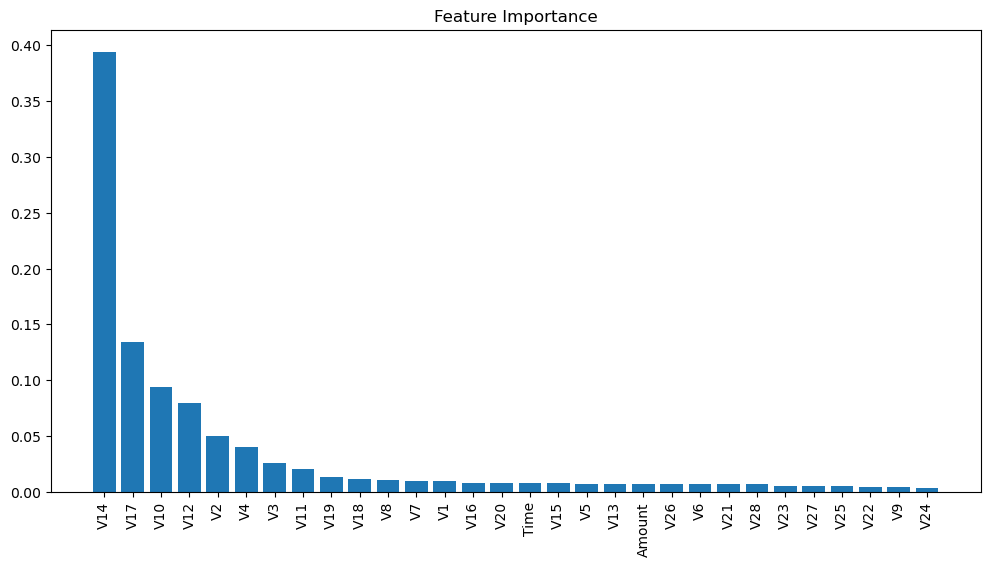

In [25]:
# Feature Importance Plot
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.show()

# CONCLUSION:


**In this project, we developed a machine learning model to detect fraudulent credit card transactions, a classic case of highly imbalanced classification. To address the severe class imbalance, we applied SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset.

We trained a Random Forest Classifier and evaluated it using metrics such as precision, recall, F1-score, and ROC-AUC, achieving a strong AUC score of 0.88. Visualizations like the pie chart helped illustrate the class imbalance, while the feature importance plot highlighted the key contributors to fraud detection.**

## Notebook Summary: Credit Card Fraud Detection
### Objective:
- Detect fraudulent credit card transactions using machine learning techniques, with a focus on addressing class imbalance.

### Tools & Techniques Used:
- Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Random Forest Classifier, SMOTE for oversampling, and evaluation metrics like Precision, Recall, F1 Score, and ROC-AUC.

#### Step 1 – Data Loading & Exploration:
- Loaded the dataset and performed basic exploration to understand the shape, features, and types of transactions.

#### Step 2 – Class Imbalance Visualization:
- Visualized the class distribution using a pie chart to highlight the severe imbalance between fraudulent and non-fraudulent transactions.

#### Step 3 – Preprocessing & Modeling:
- Applied SMOTE to balance the dataset, trained a Random Forest classifier, and evaluated it using classification metrics and ROC curve.

#### Step 4 – Feature Importance:
- Visualized the most influential features contributing to fraud detection.

### Conclusion:
- Successfully built a model to detect fraudulent transactions, handled class imbalance effectively, and assessed model performance through multiple evaluation techniques. The project demonstrated the importance of preprocessing and proper evaluation in imbalanced classification problems.